# BUS32120, Final

Kharla Loayza & Sruthi Pasupuleti

### Introduction
This analysis examines what drives the value of LEGO sets over time by combining information about set characteristics with ratings and aftermarket pricing data. The goal is to understand which features of LEGO sets are associated with higher prices and stronger value retention after retirement.

The target audience for this analysis is LEGO collectors and resellers who want to better understand which types of sets may hold or increase their value over time. For these users, factors such as set size, ratings, and retirement prices can help identify sets that perform well in the secondary market.

This analysis is motivated by the growing popularity of LEGO as a collectible asset. Some sets significantly increase in value after they are retired, but it is not always clear which characteristics contribute to that appreciation. By analyzing historical data on ratings, retail prices, and aftermarket prices, we can explore patterns that may help collectors make more informed decisions.

The key questions guiding this analysis are:What characteristics are associated with higher retail prices? Do larger sets (for example, those with more pieces) retain value better after retirement? Is there a relationship between user ratings and aftermarket price performance?


-------------------------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, accuracy_score, 
                             roc_auc_score, confusion_matrix, mean_squared_error)
from math import sqrt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Download and inspect Lego Datasets

https://rebrickable.com/downloads/

In [2]:
sets = pd.read_csv('sets.csv')
themes = pd.read_csv('themes.csv')
colors = pd.read_csv('colors.csv')
inventories = pd.read_csv('inventories.csv')
inventory_parts = pd.read_csv('inventory_parts.csv')
minifigs = pd.read_csv('minifigs.csv')
inventory_minifigs = pd.read_csv('inventory_minifigs.csv')

In [3]:
#For loop to quickly check each of the datasets above for missing values, and to view the first 3 rows of data, separated by "==="
for name, df in [('sets', sets), ('themes', themes), ('minifigs', minifigs),
                  ('colors', colors), ('inventories', inventories),
                  ('inventory_parts', inventory_parts), ('inventory_minifigs', inventory_minifigs)]:
    print(f"\n{'='*40}")
    print(f"{name.upper()} - Missing Values:")
    print(df.isnull().sum())
    print(f"\nSample:")
    print(df.head(3))


SETS - Missing Values:
set_num      0
name         0
year         0
theme_id     0
num_parts    0
img_url      0
dtype: int64

Sample:
        set_num                         name  year  theme_id  num_parts  \
0  0003977811-1  Ninjago: Book of Adventures  2022       761          1   
1         001-1                        Gears  1965       756         43   
2        0011-2            Town Mini-Figures  1979        67         12   

                                             img_url  
0  https://cdn.rebrickable.com/media/sets/0003977...  
1   https://cdn.rebrickable.com/media/sets/001-1.jpg  
2  https://cdn.rebrickable.com/media/sets/0011-2.jpg  

THEMES - Missing Values:
id             0
name           0
parent_id    150
dtype: int64

Sample:
   id            name  parent_id
0   1         Technic        NaN
1   3     Competition        1.0
2   4  Expert Builder        1.0

MINIFIGS - Missing Values:
fig_num      0
name         0
num_parts    0
img_url      0
dtype: int64

Sample:
  

Inspecting the datasets shows that the "sets", "minifigs", "inventory_minifigs", and "inventories" dtaasets have no missing values. The "themes" dataset is missing 150 parent_id values (this is for themes that do not have a parent value). The "colors" dataset is missing 2 y1 and y2 values (y1 and y2 are the years a color was first and last used, so this information is not relevant to our analysis). The "inventory_parts" dataset is missing img_url values, but this is not necessary for our analysis. 

The datasets may include promotional or non-standard sets. We will remove these by searching for any sets with 0 parts and removing them from our analysis.

In [4]:
print(f"Promotional sets with 0 parts: {(sets['num_parts'] == 0).sum()}")
print(f"Sets with 0 parts example:")
print(sets[sets['num_parts'] == 0].head())

Promotional sets with 0 parts: 6800
Sets with 0 parts example:
    set_num                                       name  year  theme_id  \
3    0011-3                 Castle 2 for 1 Bonus Offer  1987       199   
13    005-2                              Discovery Set  1967       756   
14     00-6                              Special Offer  1985        67   
15  00747-1  BIONICLE Quest for Makuta: Adventure Game  2001       741   
28    022-2                             Doll Furniture  1965       756   

    num_parts                                            img_url  
3           0  https://cdn.rebrickable.com/media/sets/0011-3.jpg  
13          0   https://cdn.rebrickable.com/media/sets/005-2.jpg  
14          0    https://cdn.rebrickable.com/media/sets/00-6.jpg  
15          0  https://cdn.rebrickable.com/media/sets/00747-1...  
28          0   https://cdn.rebrickable.com/media/sets/022-2.jpg  


There are 6,800 lego sets that have 0 parts and are special / promotional lego sets. We will now drop these from the analysis.

In [5]:
sets_clean = sets[sets['num_parts'] > 0].copy()

-------------------------------------------------------------

### Cleaning and re-formatting data

In [6]:
#For loop to quickly check the variable type for each variable in each dataset, separated by "===="
for name, df in [('sets', sets_clean), ('themes', themes), ('minifigs', minifigs),
                  ('colors', colors), ('inventories', inventories),
                  ('inventory_parts', inventory_parts), ('inventory_minifigs', inventory_minifigs)]:
    print(f"\n{'='*40}")
    print(f"{name.upper()} - Data Types:")
    print(df.info())


SETS - Data Types:
<class 'pandas.DataFrame'>
Index: 19443 entries, 0 to 26238
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   set_num    19443 non-null  str  
 1   name       19443 non-null  str  
 2   year       19443 non-null  int64
 3   theme_id   19443 non-null  int64
 4   num_parts  19443 non-null  int64
 5   img_url    19443 non-null  str  
dtypes: int64(3), str(3)
memory usage: 2.5 MB
None

THEMES - Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         490 non-null    int64  
 1   name       490 non-null    str    
 2   parent_id  340 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 17.3 KB
None

MINIFIGS - Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 16644 entries, 0 to 16643
Data columns (total 4 columns):
 #   Column     Non-Null Count  D

-------------------------------------------------------------

### Data Quality Checks

In [7]:
#Check for duplicate sets
print(f"Duplicate set_num values: {sets_clean['set_num'].duplicated().sum()}")

Duplicate set_num values: 0


In [8]:
print(f"\nTop 10 largest sets by piece count:")
print(sets_clean[['name', 'year', 'num_parts', 'theme_id']].sort_values('num_parts', ascending=False).head(10))


Top 10 largest sets by piece count:
                                    name  year  num_parts  theme_id
5125                           World Map  2021      11695       709
495                         Eiffel Tower  2022      10001       721
24463      The Ultimate Battle for Chima  2015       9987       571
481                              Titanic  2021       9092       721
462                            Colosseum  2020       9036       721
18323                         Death Star  2025       9031       171
18075                  Millennium Falcon  2017       7541       171
17660  Venusaur, Charizard and Blastoise  2026       6838       776
18207                              AT-AT  2021       6785       171
18227                    The Razor Crest  2022       6187       171


The above data check shows a set from 2026 - we are going to drop any sets from 2026 from the analysis since they are either unreleased / have not been released for long enough to be considered an investment.

In [9]:
# Drop 2026 sets
sets_clean = sets_clean[sets_clean['year'] < 2026].copy()
print(f"Rows after dropping 2026 sets: {len(sets_clean):,}")

Rows after dropping 2026 sets: 19,137


In [10]:
# Check year distribution
print(f"\nSets per decade:")
sets_clean['decade'] = (sets_clean['year'] // 10) * 10
print(sets_clean.groupby('decade')['set_num'].count())


Sets per decade:
decade
1940       5
1950     161
1960     399
1970     640
1980    1212
1990    2083
2000    3753
2010    6230
2020    4654
Name: set_num, dtype: int64


-------------------------------------------------------------

### Merging initial datasets

**Merge Sets and Themes**

In [11]:
# Rename columns in themes dataset to avoid confusion
themes_renamed = themes.rename(columns={'id': 'theme_id', 'name': 'theme_name'})

# Merge renamed themes dataset with clean sets dataset (after dropping themes columns if already in the sets dataset from a previous merge attempt)
sets_clean = sets_clean.drop(columns=[col for col in sets_clean.columns if 'theme_name' in col], errors='ignore')
sets_clean = sets_clean.merge(themes_renamed[['theme_id', 'theme_name']], on='theme_id', how='left')

sets_clean.head()

,set_num,name,year,theme_id,num_parts,img_url,decade,theme_name
0,0003977811-1,Ninjago: Book of Adventures,2022,761,1,https://cdn.rebrickable.com/media/sets/0003977...,2020,Activity Books with LEGO Parts
1,001-1,Gears,1965,756,43,https://cdn.rebrickable.com/media/sets/001-1.jpg,1960,Samsonite
2,0011-2,Town Mini-Figures,1979,67,12,https://cdn.rebrickable.com/media/sets/0011-2.jpg,1970,Classic Town
3,0012-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0012-1.jpg,1970,Supplemental
4,0013-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0013-1.jpg,1970,Supplemental


The themes info that we added to the sets dataset above is only the "sub theme". We also want to add the "parent theme" to the dataset as this may be more useful for analysis. 

In [12]:
# THEMES HAVE A PARENT-CHILD HIERARCHY
# Some themes are top-level parent themes (e.g. "Star Wars", "Technic")
# Others are sub-themes that fall under a parent (e.g. "Clone Wars" falls under "Star Wars")
# The parent_id column in themes points to the id of the parent theme
# We already merged the direct theme_name into sets_clean, but that gives us
# sub-theme names which are too granular for high level analysis
# We want to also know the top-level parent theme for each set so we can
# group sets at a higher level (e.g. group all Star Wars sub-themes together)

# Drop parent_theme_name if it already exists
sets_clean = sets_clean.drop(columns=['parent_theme_name'], errors='ignore')

# Step 1: create parent lookup table by taking themes_renamed and renaming
# columns so we can merge it back onto itself using parent_id as the join key
parent_lookup = themes_renamed[['theme_id', 'theme_name']].rename(columns={
    'theme_id': 'parent_id',
    'theme_name': 'parent_theme_name'
})

# Step 2: merge parent theme name into themes_renamed using parent_id
# This gives us both the sub-theme name and parent theme name in one table
themes_with_parent = themes_renamed.merge(parent_lookup, on='parent_id', how='left')

# Step 3: merge parent theme name into sets_clean
sets_clean = sets_clean.merge(
    themes_with_parent[['theme_id', 'parent_theme_name']],
    on='theme_id',
    how='left'
)

sets_clean.head()

,set_num,name,year,theme_id,num_parts,img_url,decade,theme_name,parent_theme_name
0,0003977811-1,Ninjago: Book of Adventures,2022,761,1,https://cdn.rebrickable.com/media/sets/0003977...,2020,Activity Books with LEGO Parts,Books
1,001-1,Gears,1965,756,43,https://cdn.rebrickable.com/media/sets/001-1.jpg,1960,Samsonite,System
2,0011-2,Town Mini-Figures,1979,67,12,https://cdn.rebrickable.com/media/sets/0011-2.jpg,1970,Classic Town,Town
3,0012-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0012-1.jpg,1970,Supplemental,Space
4,0013-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0013-1.jpg,1970,Supplemental,Space


**Merge Sets and Minifigs**

In [13]:
#Minifigs dataset is not directly linked to sets dataset in the rebrickable data
#We need minifigs because the number of mini figurines is closely linked to value
#Need to use inventories table to connect number of minifigs each set has. 
#Sets connects to inventory through set_num, and minifigs connects to inventory through inventory_id

#Drop columns from previous merge attempts
cols_to_drop = [col for col in sets_clean.columns if col.endswith('_x') or col.endswith('_y') 
                or col in ['minifig_count', 'decade']]
sets_clean = sets_clean.drop(columns=cols_to_drop, errors='ignore')

#Select the id and set_num columns from inventories table - these are the only columns we need to connect sets and minifigs
set_inventories = inventories[['id', 'set_num']].rename(columns={'id': 'inventory_id'})

#In the minifigs table, group by inventory id and then count the number of minifigs within each inventory id
minifig_counts = inventory_minifigs.groupby('inventory_id')['quantity'].sum().reset_index()
minifig_counts.rename(columns={'quantity': 'minifig_count'}, inplace=True)

#First, merge the table storing the number of minifigs for each inventory_id with the smaller inventory table only containing inventory_id and set_num
set_minifigs = set_inventories.merge(minifig_counts, on='inventory_id', how='left')

#Group by set_num 
set_minifigs = set_minifigs.groupby('set_num')['minifig_count'].sum().reset_index()

#Merge the number of minifigs into the sets dataset using set_num
sets_clean = sets_clean.merge(set_minifigs, on='set_num', how='left')
sets_clean['minifig_count'] = sets_clean['minifig_count'].fillna(0).astype(int)

sets_clean.head()

,set_num,name,year,theme_id,num_parts,img_url,theme_name,parent_theme_name,minifig_count
0,0003977811-1,Ninjago: Book of Adventures,2022,761,1,https://cdn.rebrickable.com/media/sets/0003977...,Activity Books with LEGO Parts,Books,1
1,001-1,Gears,1965,756,43,https://cdn.rebrickable.com/media/sets/001-1.jpg,Samsonite,System,0
2,0011-2,Town Mini-Figures,1979,67,12,https://cdn.rebrickable.com/media/sets/0011-2.jpg,Classic Town,Town,3
3,0012-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0012-1.jpg,Supplemental,Space,2
4,0013-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0013-1.jpg,Supplemental,Space,2


**Merge Sets and Colors**

In [14]:
#Color dataset is not directly linked to sets dataset in the rebrickable data
#Color info is in the inventory_parts table, but we need to connect inventory_parts and sets using inventory table
#Sets connects to inventory through set_num, and colors connects to inventory through color_id

# Drop any columns that might already exist from previous merge attempts
cols_to_drop = ['color_diversity']
sets_clean = sets_clean.drop(columns=cols_to_drop, errors='ignore')

#Select the inventory_id and color_id columns from inventory_parts table for core parts
inv_colors = inventory_parts[inventory_parts['is_spare'] == False][['inventory_id', 'color_id']]

#Group by inventory_id and count the unique colors for each inventory_id
color_diversity = inv_colors.groupby('inventory_id')['color_id'].nunique().reset_index()
color_diversity.rename(columns={'color_id': 'color_diversity'}, inplace=True)

#Link the color information back to the inventory table using inventory_id, and also include set_num so we can connect to set dataset
color_diversity = color_diversity.merge(
    inventories[['id', 'set_num']].rename(columns={'id': 'inventory_id'}),
    on='inventory_id', how='left'
)

#Group by set_num since each set_num will have various inventory_id
color_diversity = color_diversity.groupby('set_num')['color_diversity'].max().reset_index()

#Use set_num to merge color information to set dataset
sets_clean = sets_clean.merge(color_diversity, on='set_num', how='left')

sets_clean.head()

,set_num,name,year,theme_id,num_parts,img_url,theme_name,parent_theme_name,minifig_count,color_diversity
0,0003977811-1,Ninjago: Book of Adventures,2022,761,1,https://cdn.rebrickable.com/media/sets/0003977...,Activity Books with LEGO Parts,Books,1,1.0
1,001-1,Gears,1965,756,43,https://cdn.rebrickable.com/media/sets/001-1.jpg,Samsonite,System,0,5.0
2,0011-2,Town Mini-Figures,1979,67,12,https://cdn.rebrickable.com/media/sets/0011-2.jpg,Classic Town,Town,3,NaN
3,0012-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0012-1.jpg,Supplemental,Space,2,1.0
4,0013-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0013-1.jpg,Supplemental,Space,2,1.0


**Check sets_clean before incorporating pricing information**

In [15]:
print(f"\nMissing values:\n{sets_clean.isnull().sum()}")
print(f"\nSample:")
sets_clean.head()


Missing values:
set_num                 0
name                    0
year                    0
theme_id                0
num_parts               0
img_url                 0
theme_name              0
parent_theme_name    8888
minifig_count           0
color_diversity       228
dtype: int64

Sample:


,set_num,name,year,theme_id,num_parts,img_url,theme_name,parent_theme_name,minifig_count,color_diversity
0,0003977811-1,Ninjago: Book of Adventures,2022,761,1,https://cdn.rebrickable.com/media/sets/0003977...,Activity Books with LEGO Parts,Books,1,1.0
1,001-1,Gears,1965,756,43,https://cdn.rebrickable.com/media/sets/001-1.jpg,Samsonite,System,0,5.0
2,0011-2,Town Mini-Figures,1979,67,12,https://cdn.rebrickable.com/media/sets/0011-2.jpg,Classic Town,Town,3,NaN
3,0012-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0012-1.jpg,Supplemental,Space,2,1.0
4,0013-1,Space Mini-Figures,1979,143,12,https://cdn.rebrickable.com/media/sets/0013-1.jpg,Supplemental,Space,2,1.0


The above summary shows 8,888 missing values for parent_theme_name. This happens for sets where the theme is the top level parent theme (for example like "Harry Potter"). We are going to set the parent theme name to the theme name for these sets. 

Color_diversity has 228 missing values. This is for sets that do not appear in inventory_parts. These are likely old sets. We are going to set color_diversity to 0 for these sets. 

We are also going to drop the img_url column as it is irrelevant to our analysis.

In [16]:
# Drop img_url column
sets_clean = sets_clean.drop(columns=['img_url', 'theme_id'])

# Fill missing color_diversity values with 0
sets_clean['color_diversity'] = sets_clean['color_diversity'].fillna(0).astype(int)

# Fill missing parent_theme_name with the theme_name, because if a theme has no parent, it is the top level theme
sets_clean['parent_theme_name'] = sets_clean['parent_theme_name'].fillna(sets_clean['theme_name'])

print(f"\nMissing values:\n{sets_clean.isnull().sum()}")
sets_clean.head()


Missing values:
set_num              0
name                 0
year                 0
num_parts            0
theme_name           0
parent_theme_name    0
minifig_count        0
color_diversity      0
dtype: int64


,set_num,name,year,num_parts,theme_name,parent_theme_name,minifig_count,color_diversity
0,0003977811-1,Ninjago: Book of Adventures,2022,1,Activity Books with LEGO Parts,Books,1,1
1,001-1,Gears,1965,43,Samsonite,System,0,5
2,0011-2,Town Mini-Figures,1979,12,Classic Town,Town,3,0
3,0012-1,Space Mini-Figures,1979,12,Supplemental,Space,2,1
4,0013-1,Space Mini-Figures,1979,12,Supplemental,Space,2,1


### Merging pricing info

**Download and clean pricing data**

In [17]:
lego = pd.read_csv("lego_additional_info.csv")

lego.head()

#retire_price = Average sale price on bricklink.com at the month of retirement
#pop_price = Average sale price on bricklink.com one whole year after retirement

,set_id,set_name,release_year,theme_id,num_parts,num_figs,retail_price,num_unique_figs,set_rating,retire_month,retire_price,pop_price,Unnamed: 12
0,60244-1,Police Helicopter Transport,2020,61,317,4,39.99,3,4.6,Oct-21,37.60,37.29,NaN
1,60248-1,Fire Helicopter Response,2020,58,93,3,17.99,0,4.4,Nov-21,22.74,22.49,NaN
2,60252-1,Construction Bulldozer,2020,56,126,2,17.99,0,4.5,Nov-21,21.00,19.74,NaN
3,60254-1,Race Boat Transporter,2020,52,239,2,24.99,0,4.6,Nov-21,32.19,35.27,NaN
4,60258-1,Tuning Workshop,2020,52,897,7,89.99,6,4.6,Nov-21,86.17,95.37,NaN


In [18]:
#removing unnecesary columns
lego = lego.drop(columns=["set_name", "release_year", "theme_id","num_figs", "num_unique_figs", "num_parts", "retail_price"], errors="ignore")

In [19]:
lego = lego.loc[:, ~lego.columns.str.contains("Unnamed")]

In [20]:
#checking data types and summary statistics
lego.info()
lego.describe()

<class 'pandas.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   set_id        815 non-null    str    
 1   set_rating    815 non-null    float64
 2   retire_month  815 non-null    str    
 3   retire_price  815 non-null    float64
 4   pop_price     815 non-null    float64
dtypes: float64(3), str(2)
memory usage: 42.3 KB


,set_rating,retire_price,pop_price
count,815.000000,815.000000,815.000000
mean,4.663926,52.490845,61.644448
std,0.165662,53.755710,68.152899
min,4.200000,11.280000,11.785000
25%,4.600000,21.652500,26.132500
50%,4.700000,34.025000,39.250000
75%,4.800000,61.657500,71.415000
max,5.000000,488.710000,893.355000


In [21]:
#handling duplicates
lego = lego.drop_duplicates()

In [22]:
#ensuring numeric variables
lego["set_rating"] = pd.to_numeric(lego["set_rating"], errors="coerce")
lego["retire_price"] = pd.to_numeric(lego["retire_price"], errors="coerce")
lego["pop_price"] = pd.to_numeric(lego["pop_price"], errors="coerce")

In [23]:
#changing date format
lego["retire_month"] = pd.to_datetime(lego["retire_month"], format="%b-%y")

In [24]:
#renaming column for it to match with the other dataset
lego = lego.rename(columns={"set_id": "set_num"})

In [25]:
#checking for missing values
lego.isna().sum()

set_num         0
set_rating      0
retire_month    0
retire_price    0
pop_price       0
dtype: int64

In [26]:
lego.head()

,set_num,set_rating,retire_month,retire_price,pop_price
0,60244-1,4.6,2021-10-01,37.60,37.29
1,60248-1,4.4,2021-11-01,22.74,22.49
2,60252-1,4.5,2021-11-01,21.00,19.74
3,60254-1,4.6,2021-11-01,32.19,35.27
4,60258-1,4.6,2021-11-01,86.17,95.37


In [27]:
#final data validation
lego.info()
lego.describe()

<class 'pandas.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   set_num       815 non-null    str           
 1   set_rating    815 non-null    float64       
 2   retire_month  815 non-null    datetime64[us]
 3   retire_price  815 non-null    float64       
 4   pop_price     815 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 37.5 KB


,set_rating,retire_month,retire_price,pop_price
count,815.000000,815,815.000000,815.000000
mean,4.663926,2019-06-23 12:11:29.079754,52.490845,61.644448
min,4.200000,2016-05-01 00:00:00,11.280000,11.785000
25%,4.600000,2018-02-01 00:00:00,21.652500,26.132500
50%,4.700000,2019-03-01 00:00:00,34.025000,39.250000
75%,4.800000,2020-11-01 00:00:00,61.657500,71.415000
max,5.000000,2022-11-01 00:00:00,488.710000,893.355000
std,0.165662,NaN,53.755710,68.152899


**Merge pricing data with sets data**

In [28]:
sets_clean = sets_clean.merge(lego, on='set_num', how='left')

print(f"\nMissing values:\n{sets_clean.isnull().sum()}")
sets_clean.head()


Missing values:
set_num                  0
name                     0
year                     0
num_parts                0
theme_name               0
parent_theme_name        0
minifig_count            0
color_diversity          0
set_rating           18323
retire_month         18323
retire_price         18323
pop_price            18323
dtype: int64


,set_num,name,year,num_parts,theme_name,parent_theme_name,minifig_count,color_diversity,set_rating,retire_month,retire_price,pop_price
0,0003977811-1,Ninjago: Book of Adventures,2022,1,Activity Books with LEGO Parts,Books,1,1,NaN,NaT,NaN,NaN
1,001-1,Gears,1965,43,Samsonite,System,0,5,NaN,NaT,NaN,NaN
2,0011-2,Town Mini-Figures,1979,12,Classic Town,Town,3,0,NaN,NaT,NaN,NaN
3,0012-1,Space Mini-Figures,1979,12,Supplemental,Space,2,1,NaN,NaT,NaN,NaN
4,0013-1,Space Mini-Figures,1979,12,Supplemental,Space,2,1,NaN,NaT,NaN,NaN


18,323 datasets do not have pricing data (96% missing). While a large number, this outcome is expected because all LEGO sets are not sold or tracked on secondary markets, the dataset we are using to track pricing data scraped bricklink.com a year ago and is not fully updated, and many lego sets have not yet been retired.

In [29]:
sets_with_prices = sets_clean[sets_clean['retire_price'].notna()]
print(f"Sets with pricing data: {len(sets_with_prices):,}")
print(f"Sets without pricing data: {sets_clean['retire_price'].isna().sum():,}")
print(f"\nYear range of priced sets: {sets_with_prices['year'].min()} to {sets_with_prices['year'].max()}")

print(f"\nTop themes in priced sets:")
print(sets_with_prices['parent_theme_name'].value_counts().head(10))

Sets with pricing data: 814
Sets without pricing data: 18,323

Year range of priced sets: 2016 to 2020

Top themes in priced sets:
parent_theme_name
Star Wars              118
City                    81
Ninjago                 65
Friends                 59
Super Heroes Marvel     43
Creator                 41
Technic                 35
Minecraft               26
Juniors                 25
Speed Champions         25
Name: count, dtype: int64


-----------------------------------

### Feature Engineering

**Create new variable that measures return on investment, since the time lego set is retired**

In [30]:
#retire_price = Average sale price on bricklink.com at the month of retirement
#pop_price = Average sale price on bricklink.com one whole year after retirement

sets_clean['price_appreciation'] = (sets_clean['pop_price'] - sets_clean['retire_price']) / sets_clean['retire_price']

sets_priced = sets_clean[sets_clean['retire_price'].notna()].copy()

print(f"Price appreciation distribution:")
print(sets_priced['price_appreciation'].describe())

Price appreciation distribution:
count    814.000000
mean       0.186552
std        0.265264
min       -0.604679
25%        0.005601
50%        0.126539
75%        0.299661
max        1.371908
Name: price_appreciation, dtype: float64


**Create new binary variable to measure whether a lego set is a good investment or not**

In [31]:
sets_priced['good_investment'] = (sets_priced['price_appreciation'] > 0.20).astype(int)

print(f"Good investments: {sets_priced[sets_priced['retire_price'].notna()]['good_investment'].sum()}")
print(f"Poor investments: {(sets_priced[sets_priced['retire_price'].notna()]['good_investment'] == 0).sum()}")

Good investments: 316
Poor investments: 498


**Create new variable that tracks whether a lego set is part of a licensed theme or not**

In [32]:
# Engineered feature 1: licensed theme flag

licensed_themes = ["Winnie the Pooh","Star Wars","Mickey Mouse","Baby Mickey","Key Chain",
"Bob the builder","F1","Galidor","Spider Man","Little robots",
"Sports Basketball","Discovery","Ferrari","DUPLO","Racers",
"Dora the explorer","Go Diego Go","Thomas and friends","Batman",
"Avatar","SpongeBob SquarePants","Indiana Jones","Speed Racer",
"Rock Band","Ben 10","Cars","Prince of Persia","Toy Story",
"Pirates of the Caribbean","Marvel","DC","Ultrabuild","Disney",
"Friends","Lord of the rings","The Hobbit","Minecraft","NinjaTurtles"]
sets_clean['is_licensed'] = sets_clean['parent_theme_name'].isin(licensed_themes).astype(int)

print(f"Licensed sets: {sets_clean['is_licensed'].sum()}")
print(f"Non-licensed sets: {(sets_clean['is_licensed'] == 0).sum()}")
print(f"\nLicensed theme breakdown:")
print(sets_clean[sets_clean['is_licensed'] == 1]['parent_theme_name'].value_counts())

Licensed sets: 2523
Non-licensed sets: 16614

Licensed theme breakdown:
parent_theme_name
Star Wars                956
Friends                  616
Disney                   336
Racers                   266
Minecraft                175
Batman                    49
Cars                      25
Toy Story                 21
Indiana Jones             21
Galidor                   19
SpongeBob SquarePants     14
Avatar                     9
Discovery                  6
Ben 10                     6
Speed Racer                4
Name: count, dtype: int64


**Create new variable to measure each lego set's number of parts, relative to the number of minifigs**

In [33]:
# A lego set with more parts per minifig is considered more complex and difficult to build, vs a lego set that has more minifigs vs parts
sets_clean['parts_per_minifig'] = sets_clean.apply(
    lambda x: x['num_parts'] / x['minifig_count'] if x['minifig_count'] > 0 else x['num_parts'],
    axis=1
)

print(sets_clean[['name', 'num_parts', 'minifig_count', 'parts_per_minifig']].head(10))

                             name  num_parts  minifig_count  parts_per_minifig
0     Ninjago: Book of Adventures          1              1                1.0
1                           Gears         43              0               43.0
2               Town Mini-Figures         12              3                4.0
3              Space Mini-Figures         12              2                6.0
4              Space Mini-Figures         12              2                6.0
5              Space Mini-Figures          2              4                0.5
6              Space Mini-Figures         18              3                6.0
7             Castle Mini Figures         15              3                5.0
8  4.5V Samsonite Gears Motor Set          3              0                3.0
9             Master Mechanic Set        403              0              403.0


-----------------------------------

### Exploratory Data Analysis

In [34]:
sets_clean.head()
sets_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 19137 entries, 0 to 19136
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   set_num             19137 non-null  str           
 1   name                19137 non-null  str           
 2   year                19137 non-null  int64         
 3   num_parts           19137 non-null  int64         
 4   theme_name          19137 non-null  str           
 5   parent_theme_name   19137 non-null  str           
 6   minifig_count       19137 non-null  int64         
 7   color_diversity     19137 non-null  int64         
 8   set_rating          814 non-null    float64       
 9   retire_month        814 non-null    datetime64[us]
 10  retire_price        814 non-null    float64       
 11  pop_price           814 non-null    float64       
 12  price_appreciation  814 non-null    float64       
 13  is_licensed         19137 non-null  int64         
 14  p

In [35]:
sets_clean[['num_parts','minifig_count','color_diversity']].describe()

,num_parts,minifig_count,color_diversity
count,19137.000000,19137.000000,19137.000000
mean,223.819825,1.354340,9.707896
std,495.144016,2.948274,8.083261
min,1.000000,0.000000,0.000000
25%,18.000000,0.000000,4.000000
50%,58.000000,0.000000,8.000000
75%,221.000000,2.000000,14.000000
max,11695.000000,100.000000,57.000000


-----------------------------------

**Distribution of LEGO Set Size (Log Scale)**

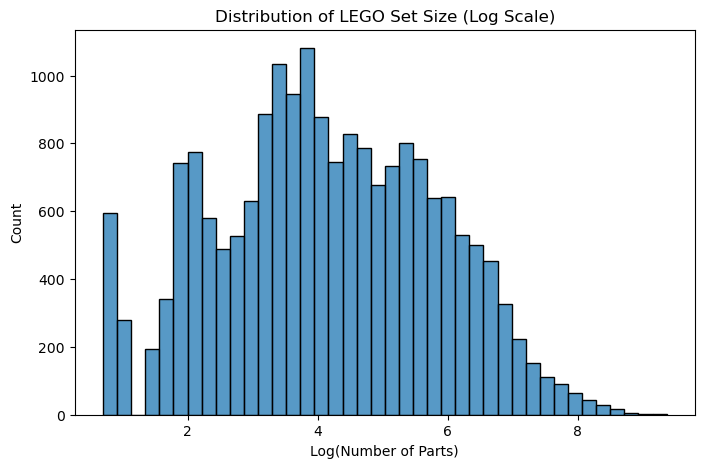

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(sets_clean["num_parts"]),
    bins=40
)

plt.title("Distribution of LEGO Set Size (Log Scale)")
plt.xlabel("Log(Number of Parts)")
plt.show()

The log-scaled histogram reveals a roughly right-skewed distribution, indicating that most LEGO sets are relatively small to medium in size, while very large sets are comparatively rare.
This pattern reflects the LEGO product portfolio strategy, where a majority of sets are designed to be accessible and affordable, while a smaller number of premium sets target advanced builders and collectors.

**Distribution of Minifigures per Set**

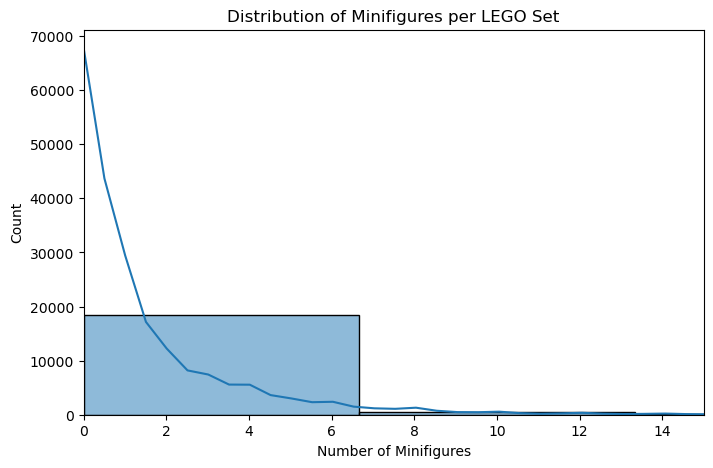

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    sets_clean["minifig_count"],
    bins=15,
    kde=True
)

plt.xlim(0,15)

plt.title("Distribution of Minifigures per LEGO Set")
plt.xlabel("Number of Minifigures")
plt.ylabel("Count")

plt.show()

The distribution of minifigures per set is highly skewed toward lower values. The majority of LEGO sets contain zero or one minifigure, with progressively fewer sets including larger numbers of characters.
This suggests that many LEGO sets focus primarily on structures, vehicles, or objects, rather than character-driven play. Sets with larger numbers of minifigures likely correspond to scene-based or narrative sets, such as those found in licensed themes.

**Minifigures per Set Counts**

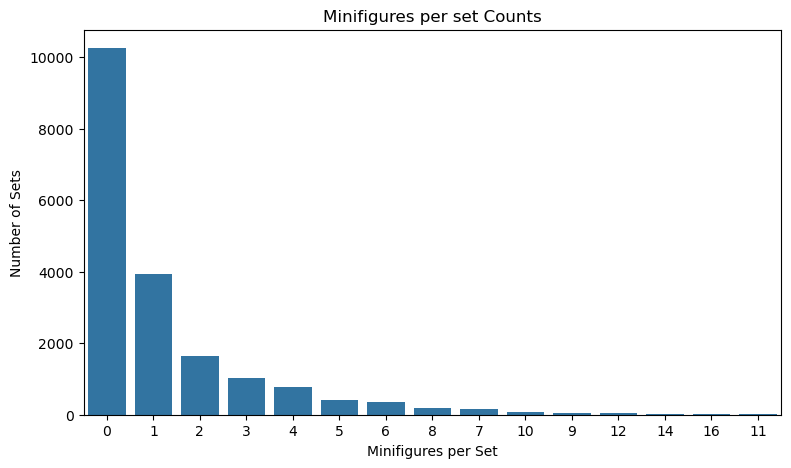

In [38]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=sets_clean,
    x="minifig_count",
    order=sets_clean["minifig_count"].value_counts().index[:15]
)

plt.title("Minifigures per set Counts")
plt.xlabel("Minifigures per Set")
plt.ylabel("Number of Sets")

plt.show()

A more detailed count analysis confirms that sets with zero minifigures are the most common. After that, the frequency declines rapidly as the number of minifigures increases.
This indicates that minifigures are typically included selectively and are not a standard feature of most sets. Sets containing larger numbers of minifigures likely represent larger or more complex playsets.

**Distribution of LEGO Set Parts per Minifig (Log Scale)**

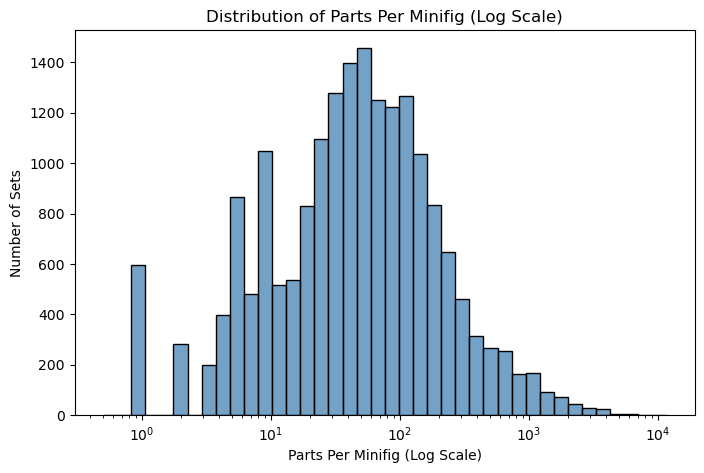

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(data=sets_clean, x='parts_per_minifig', bins=40, color='steelblue', log_scale=True)
plt.title('Distribution of Parts Per Minifig (Log Scale)')
plt.xlabel('Parts Per Minifig (Log Scale)')
plt.ylabel('Number of Sets')
plt.show()

Parts per minifig is the ratio of a lego set's total parts to total minifigures. A set is considered complex if it has a high ratio of parts to minifigs, and simple / character heavy if it has a low ratio of parts to minifigs. For instance, a high ratio set would include the Eiffel Tower, Millenium Falcon, and many architecture sets that are typically more popular with adult collectors. Low ratio sets are less likely to be collector items and are more play focused. 

Most of the lego sets cluster around the range of 10 - 100 parts per minifig. This makes sense as most lego sets have a moderate number of parts and a few minifigs. The data is right skewed due to the complex lego sets that have no or few minifigs (Eiffel Tower or Millenium Falcon). 

**Top LEGO Themes by Number of Sets**

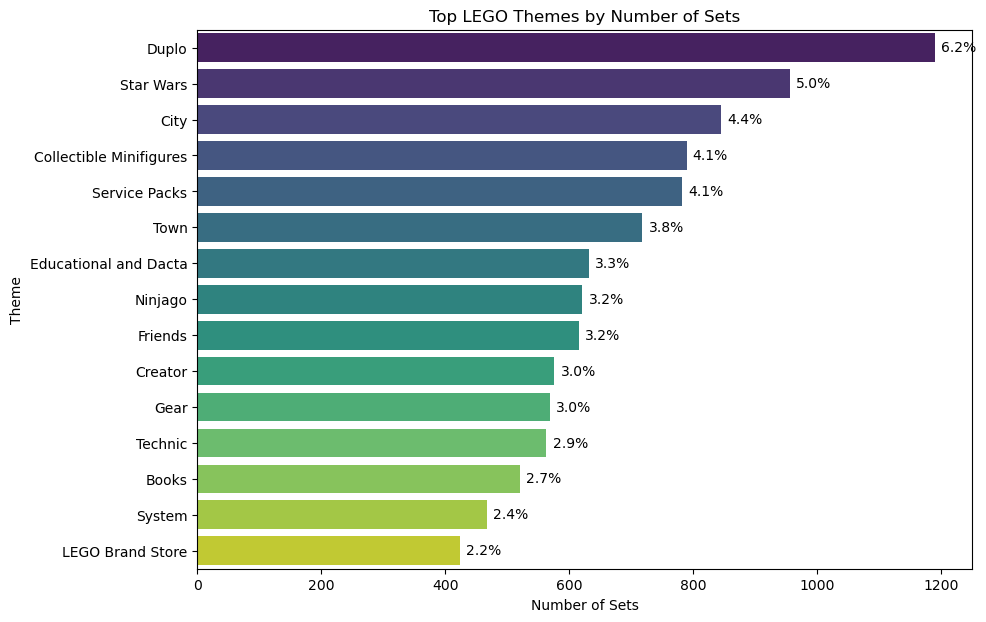

In [40]:
theme_counts = sets_clean['parent_theme_name'].value_counts()
top_themes = theme_counts.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_themes.values,
    y=top_themes.index,
    palette="viridis"
)

for i, v in enumerate(top_themes.values):
    pct = v / theme_counts.sum() * 100
    plt.text(v + 10, i, f"{pct:.1f}%", va="center")

plt.title("Top LEGO Themes by Number of Sets")
plt.xlabel("Number of Sets")
plt.ylabel("Theme")

plt.show()

The distribution of LEGO sets across themes shows that certain product lines dominate the portfolio. Duplo, Star Wars, and City represent the largest categories in terms of number of sets released, reflecting LEGO's focus on both core product lines and highly successful licensed franchises. Licensed themes tend to generate strong demand due to their association with popular media franchises, while evergreen themes like City and Creator provide consistent long-term product stability. Overall, the distribution highlights LEGO's strategy of balancing licensed franchises, classic themes, and specialized product categories to maintain a diverse and commercially successful product portfolio.

**Distribution of Color Diversity**

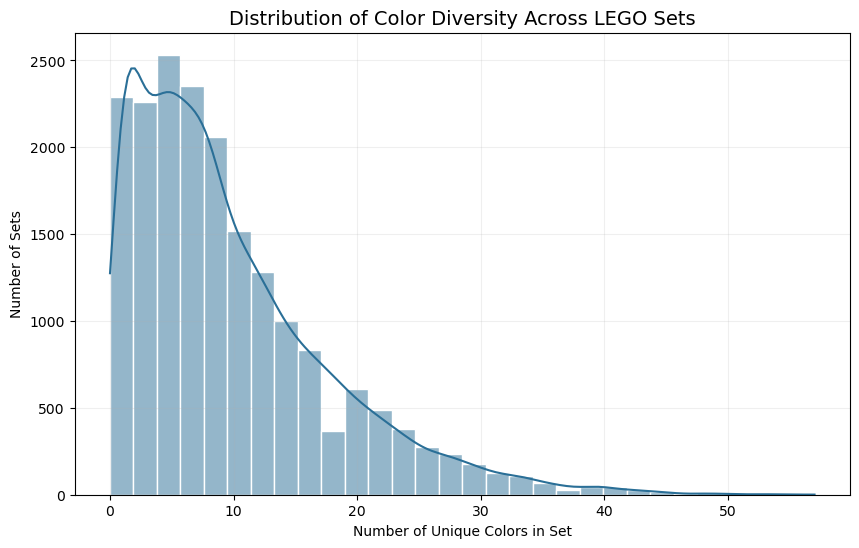

In [41]:
plt.figure(figsize=(10,6))

sns.histplot(
    sets_clean['color_diversity'],
    bins=30,
    kde=True,
    color='#2A6F97',
    edgecolor='white'
)

plt.title("Distribution of Color Diversity Across LEGO Sets", fontsize=14)
plt.xlabel("Number of Unique Colors in Set")
plt.ylabel("Number of Sets")

plt.grid(alpha=0.2)

plt.show()

The histogram of color diversity shows that most LEGO sets use a relatively limited palette of colors, typically fewer than 15. However, a smaller number of sets use a much wider range of colors, reflecting more intricate designs or highly detailed builds.
The right-skewed distribution suggests that while simple color schemes are common, some sets intentionally incorporate greater color variation to enhance realism or aesthetic complexity.

**Relationship Between Set Size and Color Diversity**

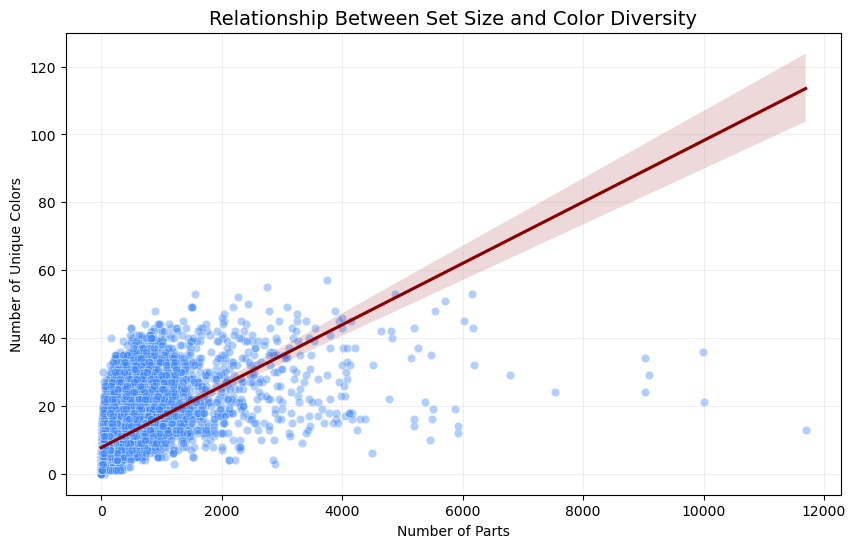

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sets_clean,
    x='num_parts',
    y='color_diversity',
    alpha=0.4,
    color='#3A86FF'
)

sns.regplot(
    data=sets_clean,
    x='num_parts',
    y='color_diversity',
    scatter=False,
    color='darkred'
)

plt.title("Relationship Between Set Size and Color Diversity", fontsize=14)
plt.xlabel("Number of Parts")
plt.ylabel("Number of Unique Colors")

plt.grid(alpha=0.2)

plt.show()

The scatterplot shows a positive relationship between the number of parts and color diversity. Larger sets tend to incorporate a greater variety of colors, likely reflecting increased structural complexity and design detail.
However, the relationship is not perfectly linear, suggesting that some large sets maintain relatively limited color palettes depending on their design theme (e.g., vehicles, architecture, or monochromatic structures).

**Relationship Between Set Size and Rating**

<Axes: xlabel='num_parts', ylabel='set_rating'>

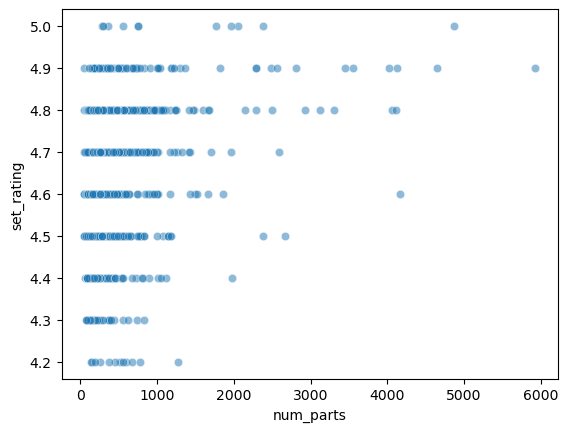

In [43]:
sns.scatterplot(
    data=sets_clean,
    x="num_parts",
    y="set_rating",
    alpha=0.5
)

The scatterplot comparing the number of parts with user ratings shows that ratings remain consistently high across sets of different sizes. Most ratings fall within a narrow range between 4.2 and 5.0, regardless of the number of parts in the set.

This suggests that set size does not strongly influence user satisfaction. Both small and large sets tend to receive similarly high ratings, indicating that LEGO is generally successful in maintaining product quality across different levels of complexity.

**Distribution of Price Appreciation Across all Lego Sets**

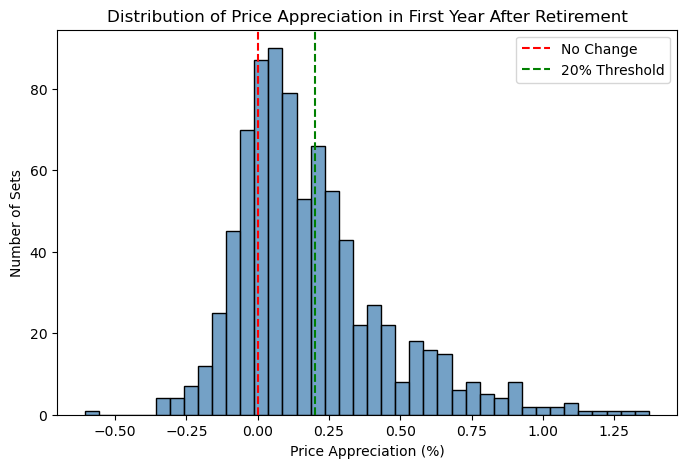

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(data=sets_priced, x='price_appreciation', bins=40, color='steelblue')
plt.title('Distribution of Price Appreciation in First Year After Retirement')
plt.xlabel('Price Appreciation (%)')
plt.ylabel('Number of Sets')
plt.axvline(x=0, color='red', linestyle='--', label='No Change')
plt.axvline(x=0.20, color='green', linestyle='--', label='20% Threshold')
plt.legend()
plt.show()

The histogram showing price appreciation for the retired sets with pricing data shows that the data is clustered around 0, and there are some lego sets that actually depereciate in value post retirement. The distribution is right skewed, so there is a small number of lego sets that appreciate significantly, but a decent number of lego sets are above the 20% threshold.

**Price Appreciation by Theme**

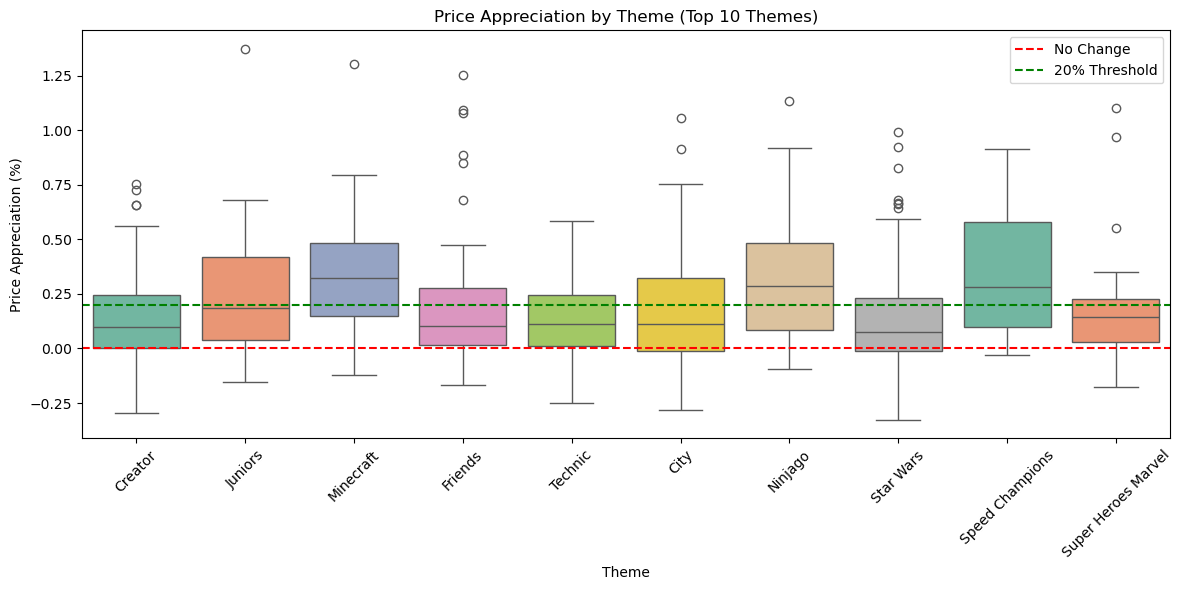

In [45]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=sets_priced[sets_priced['parent_theme_name'].isin(sets_priced['parent_theme_name'].value_counts().head(10).index)],
    x='parent_theme_name', y='price_appreciation', 
            hue='parent_theme_name', legend=False, palette='Set2')
plt.title('Price Appreciation by Theme (Top 10 Themes)')
plt.xlabel('Theme')
plt.ylabel('Price Appreciation (%)')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', label='No Change')
plt.axhline(y=0.20, color='green', linestyle='--', label='20% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

The boxplot showing price appreciation for retired lego sets with pricing data by parent theme shows that Minecraft lego sets have the highest median appreciation (above the 20% threshold). Ninjago and Speed Champions lego sets also perform well. We would have expected Star Wars lego sets to perform better, but the median appreciation is below the 20% threshold.

**Price Appreciation: Licensed vs Non-Licensed Sets**

Text(0.5, 1.0, 'Price Appreciation Distribution: Licensed vs Non-Licensed')

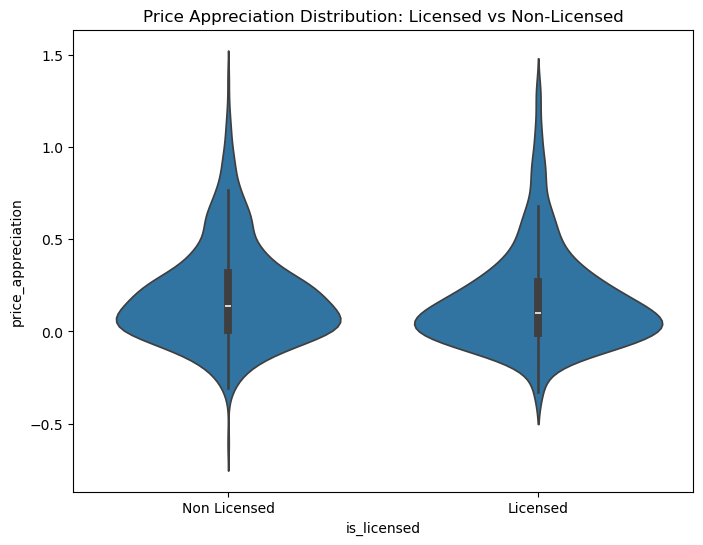

In [46]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=sets_clean,
    x="is_licensed",
    y="price_appreciation"
)

plt.xticks([0,1],["Non Licensed","Licensed"])

plt.title("Price Appreciation Distribution: Licensed vs Non-Licensed")

The violin plot comparing licensed and non-licensed sets shows that both categories exhibit wide variation in price appreciation. While licensed sets appear to have slightly higher upper ranges of appreciation, the overall distributions overlap considerably.
This suggests that licensing alone does not guarantee stronger secondary market performance. Instead, price appreciation likely depends on a combination of factors such as theme popularity, production volume, exclusivity, and collector demand.

**Set Complexity vs Price Appreciation**

Text(0, 0.5, 'Price Appreciation')

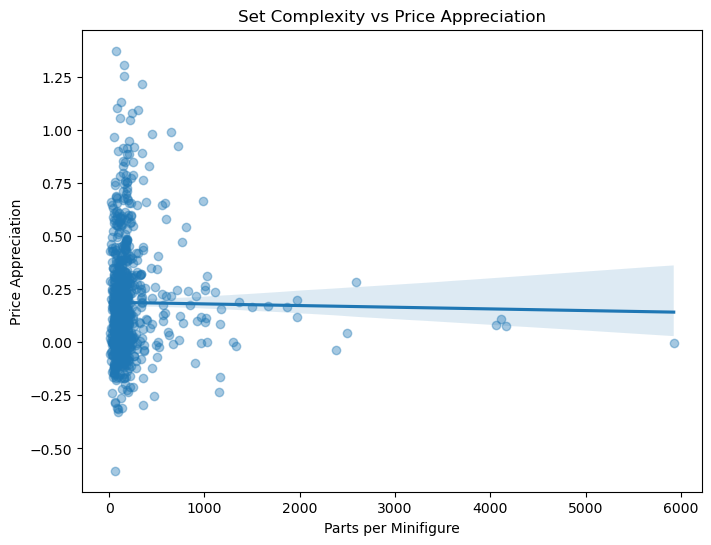

In [47]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=sets_clean,
    x="parts_per_minifig",
    y="price_appreciation",
    scatter_kws={"alpha":0.4}
)

plt.title("Set Complexity vs Price Appreciation")
plt.xlabel("Parts per Minifigure")
plt.ylabel("Price Appreciation")

The scatterplot examining the relationship between set complexity (measured by parts per minifigure) and price appreciation reveals little to no clear relationship between the two variables. While some highly complex sets achieve strong appreciation, many do not, and several simpler sets also show positive investment performance.
The nearly flat regression line indicates that structural complexity alone is not a strong predictor of price appreciation. This suggests that other factors, such as theme popularity, rarity, licensing, or collector demand, may play a more important role in determining secondary market value.

**Distribution of Good Investments**

<Axes: xlabel='good_investment', ylabel='count'>

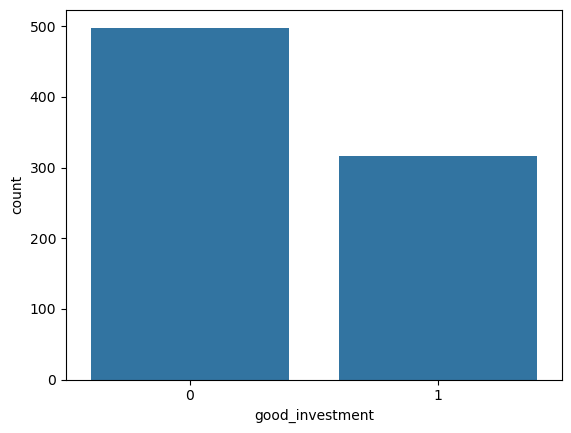

In [48]:
sns.countplot(data=sets_priced, x='good_investment')

The count plot shows the distribution of sets classified as good investments versus those that did not meet the investment threshold. While a significant number of sets are classified as good investments, the majority fall into the non-investment category, suggesting that strong price appreciation is relatively uncommon.
This highlights that although LEGO sets can appreciate in value, only a subset of releases generate strong returns in the secondary market.

**Best Performing LEGO Themes (Based on % of Sets Within Theme that Appreciate > 20%)**

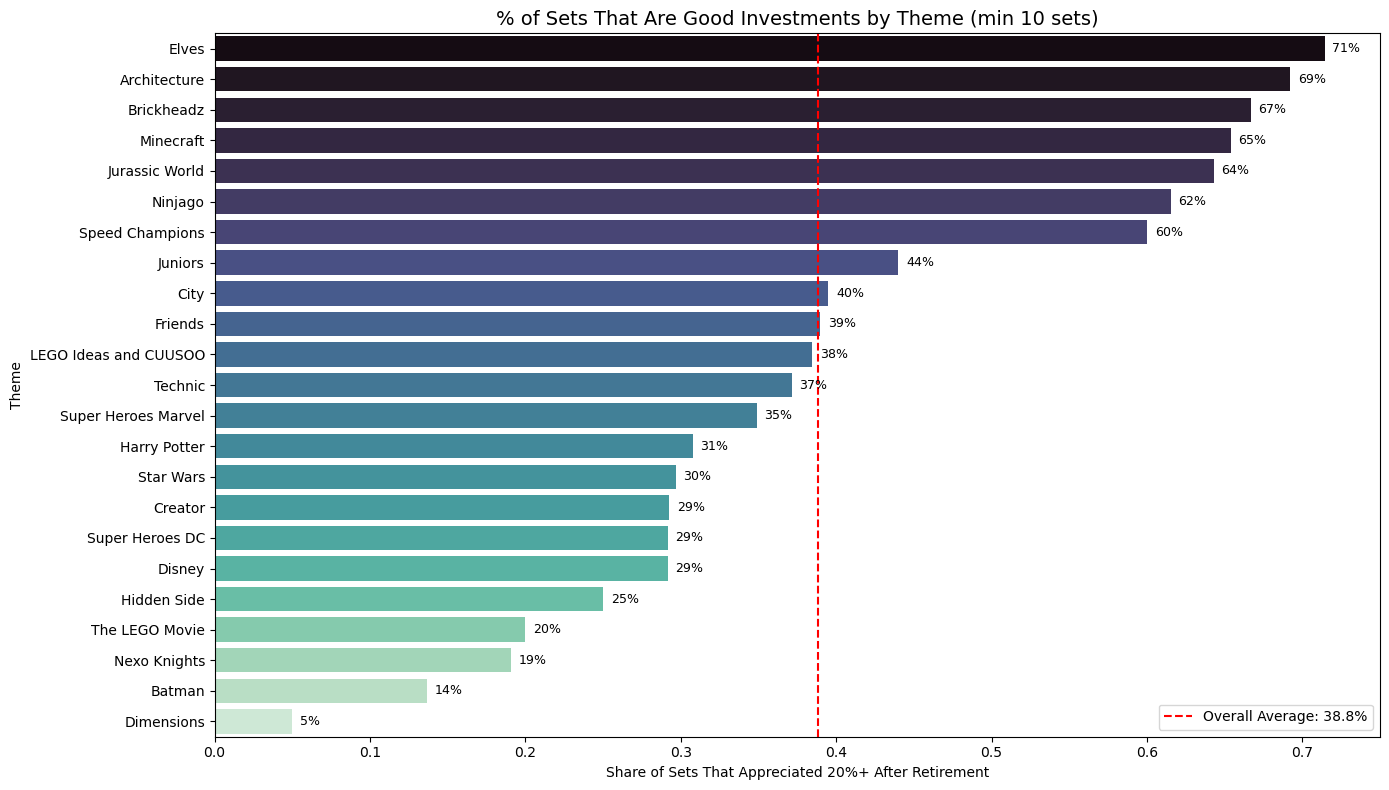

In [49]:
theme_investment = sets_priced.groupby('parent_theme_name')['good_investment'].agg(['mean', 'count']).reset_index()
theme_investment = theme_investment[theme_investment['count'] >= 10].sort_values('mean', ascending=False)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=theme_investment,
    x="mean",
    y="parent_theme_name",
    palette="mako"
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.0%}",
        va='center', fontsize=9
    )

plt.axvline(0.388, color="red", linestyle="--", label="Overall Average: 38.8%")
plt.title("% of Sets That Are Good Investments by Theme (min 10 sets)", fontsize=14)
plt.xlabel("Share of Sets That Appreciated 20%+ After Retirement")
plt.ylabel("Theme")
plt.legend()
plt.tight_layout()
plt.show()

The analysis of investment performance across themes shows that certain themes outperform others in terms of price appreciation. Themes such as Elves, Architecture, and Brickheadz demonstrate the highest investment success rates, which is surprising given that more popular themes like Star Wars and Harry Potter perform below the overall average. Minecraft and Jurassic World also show strong performance. This suggests that collectible-oriented themes or those targeting adult collectors may perform better in the secondary market than mass-market franchises. Most themes fall below the overall average, indicating that strong price appreciation is the exception rather than the rule.

**Best Performing LEGO Themes (Based on Avg Price Appreciation)**

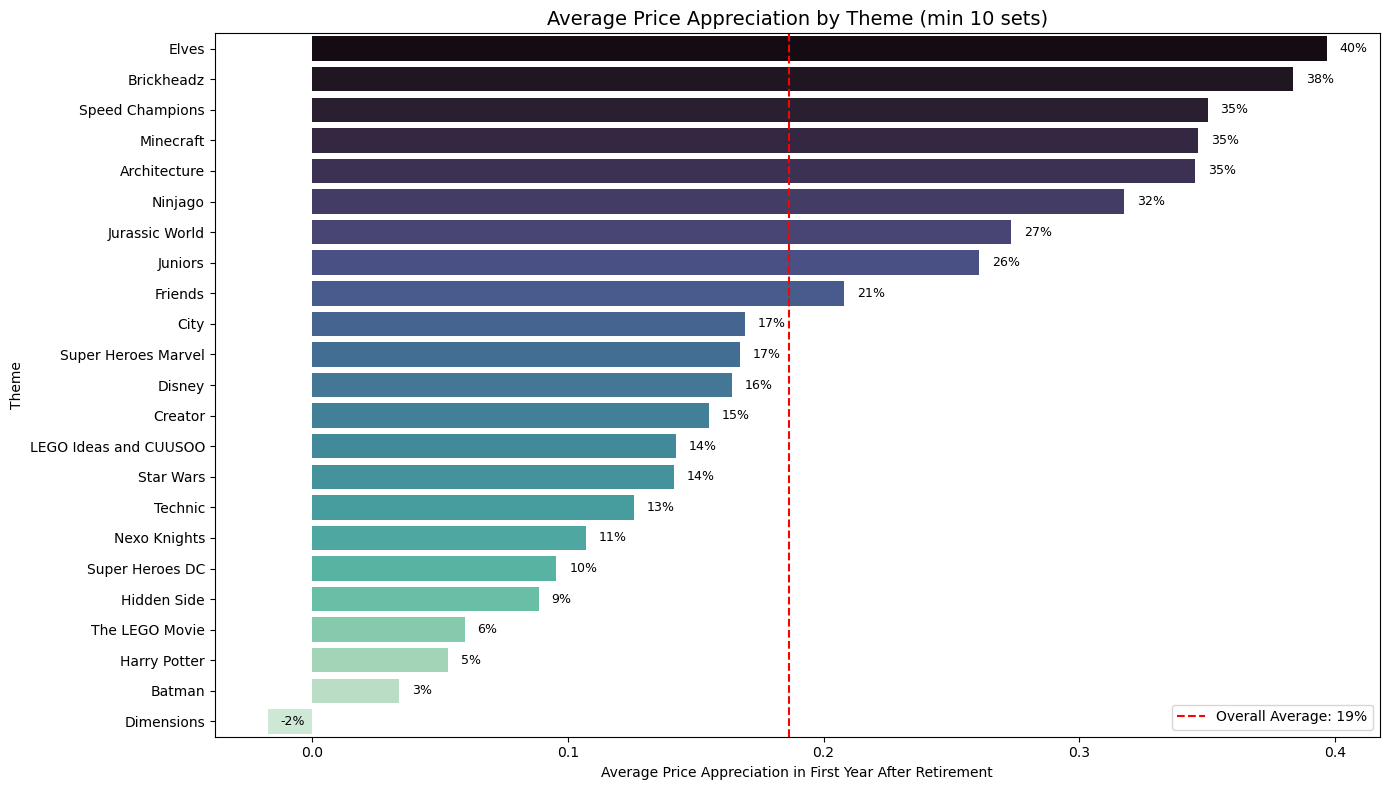

In [50]:
theme_appreciation = sets_priced.groupby('parent_theme_name')['price_appreciation'].agg(['mean', 'count']).reset_index()
theme_appreciation = theme_appreciation[theme_appreciation['count'] >= 10].sort_values('mean', ascending=False)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=theme_appreciation,
    x="mean",
    y="parent_theme_name",
    palette="mako"
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.0%}",
        va='center', fontsize=9
    )

plt.axvline(sets_priced['price_appreciation'].mean(), color="red", linestyle="--", label=f"Overall Average: {sets_priced['price_appreciation'].mean():.0%}")
plt.title("Average Price Appreciation by Theme (min 10 sets)", fontsize=14)
plt.xlabel("Average Price Appreciation in First Year After Retirement")
plt.ylabel("Theme")
plt.legend()
plt.tight_layout()
plt.show()

The Elves, Brickheadz, and Speed Champions sets have the highest average price appreciation. This represents a small shift compared to the previous investment rate chart, indicating that a theme having a high share of good investment does not necessarily mean that theme has the highest average appreciation. Jurassic World had the 5th highest investment rate, but is 7th for average appreciation, indicating sets within Jurassic World meat the 20% threshold frequently, but not by a large margin. Most of the themes are below the overall average appreciation of 19%.

Looking only at the percentage of sets within a theme that meet the good investment criteria is not enough. Doing so showed that the Dimensions theme has 5% of sets qualifying as good investments, but the theme has overall negative price appreciation. This indicates that a outlier sets within the theme were masking the theme's overall poor performance.

**Correlation Matrix of LEGO Set Features**

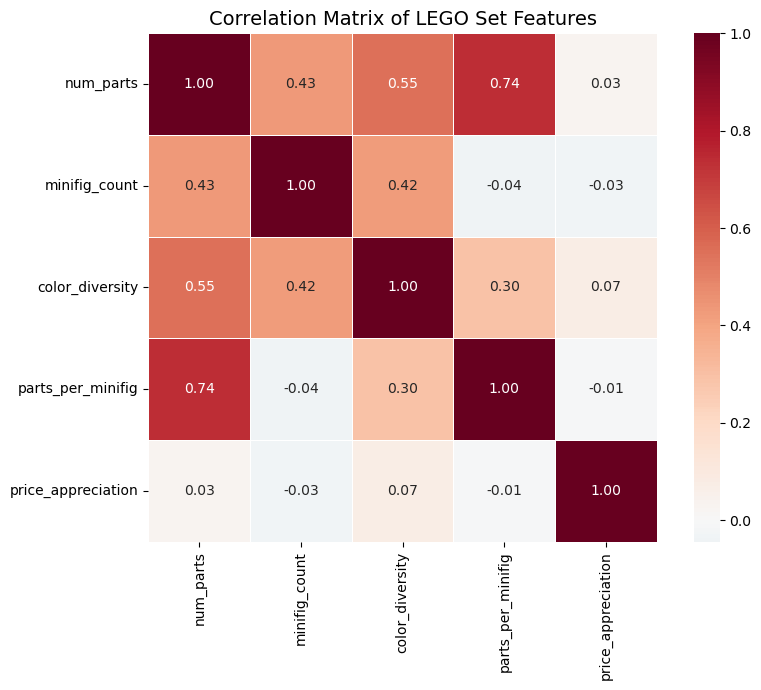

In [51]:
plt.figure(figsize=(9,7))

corr_matrix = sets_clean[
    ['num_parts','minifig_count','color_diversity','parts_per_minifig','price_appreciation']
].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of LEGO Set Features", fontsize=14)
plt.tight_layout()

plt.show()

The number of parts shows a strong positive correlation with parts per minifigure (0.74) and a moderate correlation with color diversity (0.55), indicating that larger sets tend to be more complex both structurally and visually.

Minifigure count is moderately correlated with both set size and color diversity, suggesting that sets with more characters often include additional design elements and accessories.
In contrast, price appreciation exhibits almost no correlation with structural features, implying that secondary market performance is likely driven more by factors such as theme popularity, licensing, rarity, or collector demand rather than purely physical characteristics of the set.

### SQL

In [52]:
sets_clean.head()

,set_num,name,year,num_parts,theme_name,parent_theme_name,minifig_count,color_diversity,set_rating,retire_month,retire_price,pop_price,price_appreciation,is_licensed,parts_per_minifig
0,0003977811-1,Ninjago: Book of Adventures,2022,1,Activity Books with LEGO Parts,Books,1,1,NaN,NaT,NaN,NaN,NaN,0,1.0
1,001-1,Gears,1965,43,Samsonite,System,0,5,NaN,NaT,NaN,NaN,NaN,0,43.0
2,0011-2,Town Mini-Figures,1979,12,Classic Town,Town,3,0,NaN,NaT,NaN,NaN,NaN,0,4.0
3,0012-1,Space Mini-Figures,1979,12,Supplemental,Space,2,1,NaN,NaT,NaN,NaN,NaN,0,6.0
4,0013-1,Space Mini-Figures,1979,12,Supplemental,Space,2,1,NaN,NaT,NaN,NaN,NaN,0,6.0


In [53]:
import sqlite3
conn = sqlite3.connect(":memory:")
sets_clean.to_sql("sets_clean", conn, index=False)
sets_priced.to_sql("sets_priced", conn, index=False)

814

**Sets released per year**

In [54]:
# Query 1: Count how many LEGO sets were released each year.
# What it does:
# This query shows the number of sets released per year.
# How it works:
# It groups rows by year and counts the number of sets in each group.
# Why it matters:
# This helps identify whether LEGO's product output increased or decreased over time.

query1 = """
SELECT
    year,
    COUNT(*) AS total_sets,
    SUM(is_licensed) AS licensed_sets,
    COUNT(*) - SUM(is_licensed) AS non_licensed_sets
FROM sets_clean
GROUP BY year
ORDER BY year;
"""

pd.read_sql(query1, conn)

,year,total_sets,licensed_sets,non_licensed_sets
0,1949,5,0,5
1,1950,6,0,6
2,1953,3,0,3
3,1954,14,0,14
4,1955,36,0,36
...,...,...,...,...
70,2021,763,128,635
71,2022,723,122,601
72,2023,756,155,601
73,2024,820,160,660


Annual set releases have grown over time, and the most recent years have had the highest output. This reflects Lego's expansion into new themes and licensed partnerships.

**Top Lego Themes by Number of Sets**

In [55]:
# Query 2: Find the parent themes with the largest number of LEGO sets.
# What it does:
# This query counts how many sets belong to each parent theme.
# How it works:
# It groups rows by parent_theme_name and counts the number of sets in each theme.
# Why it matters:
# This helps identify LEGO's most represented product categories.

query2 = """
SELECT
    parent_theme_name,
    COUNT(*) AS total_sets
FROM sets_clean
GROUP BY parent_theme_name
ORDER BY total_sets DESC
LIMIT 10;
"""

pd.read_sql(query2, conn)

,parent_theme_name,total_sets
0,Duplo,1190
1,Star Wars,956
2,City,845
3,Collectible Minifigures,789
4,Service Packs,782
5,Town,718
6,Educational and Dacta,631
7,Ninjago,621
8,Friends,616
9,Creator,576


Duplo, Star Wars, and City have the highest number of sets. Lego has a strategy of growing its licensed (Star Wars) and core product (City) sets.

**Licensed vs Non-Licensed Sets**

In [56]:
# Query 3: Compare licensed and non-licensed sets.
# What it does:
# This query compares the number of sets and average structural characteristics
# for licensed versus non-licensed sets.
# How it works:
# It groups rows by is_licensed and calculates counts and averages for each group.
# Why it matters:
# This helps test whether licensed sets are systematically different from non-licensed sets.

query3 = """
SELECT
    CASE
        WHEN is_licensed = 1 THEN 'Licensed'
        ELSE 'Non-Licensed'
    END AS license_type,
    COUNT(*) AS total_sets,
    AVG(num_parts) AS avg_num_parts,
    AVG(minifig_count) AS avg_minifigs,
    AVG(color_diversity) AS avg_color_diversity,
    AVG(set_rating) AS avg_rating
FROM sets_clean
GROUP BY is_licensed;
"""

pd.read_sql(query3, conn)

,license_type,total_sets,avg_num_parts,avg_minifigs,avg_color_diversity,avg_rating
0,Non-Licensed,16614,209.493379,1.233117,9.030095,4.673665
1,Licensed,2523,318.159730,2.152596,14.171225,4.642063


Licensed sets have more minifigures and higher ratings on average, than non-liensed sets. Non-licsensed sets have a higher number of parts. This is because licensed sets are more character focused, and non-licensed sets tend to have more complex builds.

**Join Pricing Data**

In [57]:
# Query 4: Join LEGO set features with pricing information.
# What it does:
# This query combines structural set characteristics with market pricing data.
# How it works:
# It joins sets_clean and sets_priced using set_num, the unique set identifier.
# Why it matters:
# This creates the base needed to analyze how product characteristics relate to investment outcomes.

query4 = """
SELECT
    s.set_num,
    s.name,
    s.year,
    s.parent_theme_name,
    s.num_parts,
    s.minifig_count,
    s.color_diversity,
    p.retire_price,
    p.pop_price,
    p.price_appreciation,
    p.good_investment
FROM sets_clean s
INNER JOIN sets_priced p
    ON s.set_num = p.set_num
LIMIT 20;
"""

pd.read_sql(query4, conn)

,set_num,name,year,parent_theme_name,num_parts,minifig_count,color_diversity,retire_price,pop_price,price_appreciation,good_investment
0,10251-1,Brick Bank,2016,Modular Buildings,2384,10,39,155.285,202.150,0.301800,1
1,10252-1,Volkswagen Beetle,2016,Creator,1167,0,19,118.900,129.075,0.085576,0
2,10253-1,Big Ben,2016,Creator,4167,0,18,205.970,222.140,0.078507,0
3,10254-1,Winter Holiday Train,2016,Christmas,735,10,28,95.415,154.030,0.614316,1
4,10256-1,Taj Mahal,2017,Creator,5923,0,14,397.710,396.105,-0.004036,0
5,10257-1,Carousel,2017,Creator,2670,14,27,191.350,330.345,0.726391,1
6,10259-1,Winter Village Station,2017,Christmas,902,5,26,81.010,91.650,0.131342,0
7,10260-1,Downtown Diner,2018,Modular Buildings,2480,12,29,212.535,275.940,0.298327,1
8,10261-1,Roller Coaster,2018,Creator,4124,22,32,426.760,442.800,0.037586,0
9,10262-1,James Bond Aston Martin DB5,2018,Creator,1297,0,18,178.230,178.045,-0.001038,0


The joined table includes all data for which we have pricing information.

**Average Price Appreciation by Lego Set Theme**

In [58]:
# Query 5: Measure average price appreciation by parent theme.
# What it does:
# This query calculates the average resale appreciation for each parent theme.
# How it works:
# It joins the clean set table with the priced set table and groups by parent_theme_name.
# Why it matters:
# This helps identify which themes tend to perform better in the secondary market.

query5 = """
SELECT
    s.parent_theme_name,
    COUNT(*) AS priced_sets,
    AVG(p.price_appreciation) AS avg_price_appreciation
FROM sets_clean s
INNER JOIN sets_priced p
    ON s.set_num = p.set_num
GROUP BY s.parent_theme_name
HAVING COUNT(*) >= 10
ORDER BY avg_price_appreciation DESC;
"""

pd.read_sql(query5, conn)

,parent_theme_name,priced_sets,avg_price_appreciation
0,Elves,14,0.396923
1,Brickheadz,15,0.383571
2,Speed Champions,25,0.350261
3,Minecraft,26,0.346416
4,Architecture,13,0.345221
5,Ninjago,65,0.317671
6,Jurassic World,14,0.273406
7,Juniors,25,0.260733
8,Friends,59,0.207917
9,City,81,0.169215


Average price appreciation varies greatly by theme. It appears that niche or collectible themes outperform other themes, so scarcity and collector demand may drive appreciation.

**Share of good investments by Theme**

In [59]:
# Query 6: Calculate the share of good investments by theme.
# What it does:
# This query measures how often sets in each parent theme are classified as good investments.
# How it works:
# It joins the two tables and averages the binary variable good_investment for each theme.
# Why it matters:
# This helps identify the themes with the strongest investment success rate.

query6 = """
SELECT
    s.parent_theme_name,
    COUNT(*) AS priced_sets,
    AVG(p.good_investment) AS percentage_good_investment
FROM sets_clean s
INNER JOIN sets_priced p
    ON s.set_num = p.set_num
GROUP BY s.parent_theme_name
HAVING COUNT(*) >= 10
ORDER BY percentage_good_investment DESC;
"""

pd.read_sql(query6, conn)

,parent_theme_name,priced_sets,percentage_good_investment
0,Elves,14,0.714286
1,Architecture,13,0.692308
2,Brickheadz,15,0.666667
3,Minecraft,26,0.653846
4,Jurassic World,14,0.642857
5,Ninjago,65,0.615385
6,Speed Champions,25,0.600000
7,Juniors,25,0.440000
8,City,81,0.395062
9,Friends,59,0.389831


Themes with highest share of good investments are not necessarily the most popular ones. We would have expected to see themes like Harry Potter and Star Wars, higher on the list. Investment performance is not simply tied to brand recognition.

**Themes with above average price appreciation**

In [60]:
# Query 7: Find themes whose average appreciation is above the overall average.
# What it does:
# This query identifies themes that outperform the full priced dataset in appreciation.
# How it works:
# It uses a subquery to compute the overall average price appreciation, then compares each theme to it.
# Why it matters:
# This provides a stronger benchmark for identifying above-average market performers.

query7 = """
SELECT
    s.parent_theme_name,
    AVG(p.price_appreciation) AS avg_price_appreciation
FROM sets_clean s
INNER JOIN sets_priced p
    ON s.set_num = p.set_num
GROUP BY s.parent_theme_name
HAVING AVG(p.price_appreciation) > (
    SELECT AVG(price_appreciation)
    FROM sets_priced
)
ORDER BY avg_price_appreciation DESC;
"""

pd.read_sql(query7, conn)

,parent_theme_name,avg_price_appreciation
0,Bionicle,0.643441
1,Stranger Things,0.422124
2,Elves,0.396923
3,Overwatch,0.388147
4,Classic,0.388072
5,Brickheadz,0.383571
6,Speed Champions,0.350261
7,Minecraft,0.346416
8,Architecture,0.345221
9,Forma,0.328749


The themes that outperform the average price appreciation are smaller, more collectible lines, vs mainstream franchises. Again, we would have expected to see themes with more brand recognition / popularity higher on the list.

**Best lego set per theme based on price appreciation**

In [61]:
# Query 8: Rank sets within each theme by price appreciation, and shows the top set per theme
# What it does:
# This query ranks each priced set against other sets within the same theme.
# How it works:
# It uses a window function (RANK) partitioned by parent_theme_name to assign
# a rank based on price appreciation, without collapsing rows.
# Why it matters:
# This identifies the top performing set within each theme.

query8 = """
SELECT *
FROM (
    SELECT
        s.set_num,
        s.name,
        s.parent_theme_name,
        p.price_appreciation,
        RANK() OVER (PARTITION BY s.parent_theme_name ORDER BY p.price_appreciation DESC) AS rank_within_theme
    FROM sets_clean s
    INNER JOIN sets_priced p
        ON s.set_num = p.set_num
) ranked
WHERE rank_within_theme = 1
ORDER BY price_appreciation DESC;
"""

pd.read_sql(query8, conn)

,set_num,name,parent_theme_name,price_appreciation,rank_within_theme
0,10727-1,Emma's Ice Cream Truck,Juniors,1.371908,1
1,21148-1,Minecraft Steve BigFig with Parrot,Minecraft,1.304662,1
2,41345-1,Heartlake City Pet Center,Friends,1.254452,1
3,41176-1,The Secret Market Place,Elves,1.215137,1
4,70652-1,Stormbringer,Ninjago,1.131482,1
5,76103-1,Corvus Glaive Thresher Attack,Super Heroes Marvel,1.101814,1
6,60182-1,Pickup & Caravan,City,1.053310,1
7,41627-1,Luke Skywalker & Yoda,Brickheadz,1.046104,1
8,75276-1,Stormtrooper,Star Wars,0.989729,1
9,11004-1,Windows of Creativity,Classic,0.980376,1


The top performing lego set within each theme outperforms the theme average by a high margin. This could indicate that within each theme, there is a small number of sets driving outsized performance.

**Lego sets that outperform theme average price appreciation**

In [62]:
# Query 9: Show each set's appreciation relative to its theme average, if the set outperforms its theme average
# What it does:
# This query calculates how much each set over or underperforms vs its theme average.
# How it works:
# It uses a window function (AVG OVER PARTITION BY) to compute the theme-level
# average alongside each individual set's appreciation.
# Why it matters:
# This helps identify standout sets within themes that otherwise perform poorly.

query9 = """
SELECT *
FROM (
    SELECT
        s.set_num,
        s.name,
        s.parent_theme_name,
        p.price_appreciation,
        AVG(p.price_appreciation) OVER (PARTITION BY s.parent_theme_name) AS theme_avg_appreciation,
        p.price_appreciation - AVG(p.price_appreciation) OVER (PARTITION BY s.parent_theme_name) AS vs_theme_avg
    FROM sets_clean s
    INNER JOIN sets_priced p
        ON s.set_num = p.set_num
) themed
WHERE vs_theme_avg > 0
ORDER BY vs_theme_avg DESC;
"""

pd.read_sql(query9, conn)

,set_num,name,parent_theme_name,price_appreciation,theme_avg_appreciation,vs_theme_avg
0,10727-1,Emma's Ice Cream Truck,Juniors,1.371908,0.260733,1.111175
1,41345-1,Heartlake City Pet Center,Friends,1.254452,0.207917,1.046534
2,21148-1,Minecraft Steve BigFig with Parrot,Minecraft,1.304662,0.346416,0.958246
3,76103-1,Corvus Glaive Thresher Attack,Super Heroes Marvel,1.101814,0.167250,0.934564
4,41135-1,Livi's Pop Star House,Friends,1.093026,0.207917,0.885108
...,...,...,...,...,...,...
344,41067-1,Belle's Enchanted Castle,Disney,0.167415,0.164104,0.003311
345,76129-1,Hydro-Man Attack,Super Heroes Marvel,0.170241,0.167250,0.002991
346,75531-1,Stormtrooper Commander,Star Wars,0.142099,0.141336,0.000763
347,75972-1,Dorado Showdown,Overwatch,0.388640,0.388147,0.000494


Individual sets can significantly outperform the theme average, so it is not sufficient to only look at theme level data.

**Lego sets that outperform theme average and overall average price appreciation**

In [63]:
# Query 10: Find sets that outperform both their theme average and the overall average.
# What it does:
# This query identifies sets that beat two benchmarks simultaneously.
# How it works:
# It uses a subquery to find the overall average, and a second subquery to find
# each theme's average, then filters for sets that exceed both.
# Why it matters:
# These are the strongest investment candidates in the dataset.

query10 = """
SELECT
    s.set_num,
    s.name,
    s.parent_theme_name,
    p.price_appreciation
FROM sets_clean s
INNER JOIN sets_priced p
    ON s.set_num = p.set_num
WHERE p.price_appreciation > (SELECT AVG(price_appreciation) FROM sets_priced)
AND p.price_appreciation > (
    SELECT AVG(p2.price_appreciation)
    FROM sets_clean s2
    INNER JOIN sets_priced p2 ON s2.set_num = p2.set_num
    WHERE s2.parent_theme_name = s.parent_theme_name
)
ORDER BY p.price_appreciation DESC;
"""

pd.read_sql(query10, conn)

,set_num,name,parent_theme_name,price_appreciation
0,10727-1,Emma's Ice Cream Truck,Juniors,1.371908
1,21148-1,Minecraft Steve BigFig with Parrot,Minecraft,1.304662
2,41345-1,Heartlake City Pet Center,Friends,1.254452
3,41176-1,The Secret Market Place,Elves,1.215137
4,70652-1,Stormbringer,Ninjago,1.131482
...,...,...,...,...
280,75195-1,Ski Speeder vs First Order Walker Microfighters,Star Wars,0.190313
281,75246-1,Death Star Cannon,Star Wars,0.189349
282,31091-1,Shuttle Transporter,Creator,0.188651
283,60121-1,Volcano Exploration Truck,City,0.188361


The lego sets that outperform the overall average and their theme average are the strongest investment opportunities. These lego sets again seem to follow the pattern of being collective oriented lines.

### Modeling

In [64]:
#For modeling we will only use the data that contains pricing information
sets_priced = sets_clean[sets_clean['retire_price'].notna()].copy()
sets_priced['good_investment'] = (sets_priced['price_appreciation'] > 0.20).astype(int)
model_df = sets_priced.copy()
model_df['good_investment'] = (model_df['price_appreciation'] > 0.20).astype(int)

print(model_df.columns.tolist())

['set_num', 'name', 'year', 'num_parts', 'theme_name', 'parent_theme_name', 'minifig_count', 'color_diversity', 'set_rating', 'retire_month', 'retire_price', 'pop_price', 'price_appreciation', 'is_licensed', 'parts_per_minifig', 'good_investment']


**Linear Model**

With the linear model we are exploring if we can determine how much a lego set will appreciate one year after retirement, using certain characteristics of the lego set. By answering this question, lego investors should have a better idea of what sets to invest in before the sets are retired.

In [65]:
X = model_df[['num_parts', 'minifig_count', 'color_diversity', 'is_licensed', 'parts_per_minifig']]
y = model_df['price_appreciation']

print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (814, 5)
y shape:  (814,)


In [66]:
# 80% data used for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X train = ", X_train.shape)
print("y train = ", y_train.shape)
print("\nX test = ", X_test.shape)
print("y test = ", y_test.shape)

X train =  (651, 5)
y train =  (651,)

X test =  (163, 5)
y test =  (163,)


In [67]:
linear_fit = LinearRegression()
linear_fit.fit(X_train, y_train)

# R-squared
score = linear_fit.score(X_test, y_test)
print('R-square = ', f'{score:.3f}')

# Feature coefficients
print('\nFeature coefficients:')
for feature, coef in zip(X_train.columns, linear_fit.coef_):
    print(feature, ':', f'{coef:.4f}')

R-square =  -0.007

Feature coefficients:
num_parts : 0.0001
minifig_count : -0.0127
color_diversity : 0.0041
is_licensed : -0.0379
parts_per_minifig : -0.0001


The R^2 value of -0.007 indicates that this model is not performing well. price_appreciation for the lego sets 1 year after retirement is difficult to predict using the variables we have included (number of parts, minifig count, color diversity, licensing, and the ratio of parts to minifigs). 

In [68]:
y_predicted = linear_fit.predict(X_test)
rmse = sqrt(mean_squared_error(y_test, y_predicted))
print("RMSE = ", f'{rmse:.4f}')

RMSE =  0.2580


On average, the linear model's predictions vary from the actual results by 26%. This is a very wide range for error. If a lego set truly appreciated in value by 20%, the model could predict appreciation in a range of -4% - 46%. 

The model does not have strong predictive power and this may be due to the model not including critical variables. Further data on social media / popularity, nostalgia, production quantity, etc. could improve the model. 

**Logistic Model**

With the logistic model we are determining whether a lego set is a good investment or not (a binary outcome) based on certain characteristics of the lego set. Again, this information should help lego investors with making better choices on what lego sets to purchase before they are retired.

In [69]:
X_log = model_df[['num_parts', 'minifig_count', 'color_diversity', 'is_licensed', 'parts_per_minifig']]
y_log = model_df['good_investment']

print("X shape: ", X_log.shape)
print("y shape: ", y_log.shape)
print("\nTarget distribution:")
print(y_log.value_counts())

X shape:  (814, 5)
y shape:  (814,)

Target distribution:
good_investment
0    498
1    316
Name: count, dtype: int64


In [70]:
# again, use 80% of data for training, 20% to test
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

print("X train = ", X_train_log.shape)
print("y train = ", y_train_log.shape)
print("\nX test = ", X_test_log.shape)
print("y test = ", y_test_log.shape)

X train =  (651, 5)
y train =  (651,)

X test =  (163, 5)
y test =  (163,)


In [71]:
logistic_fit = LogisticRegression(max_iter=1000)
logistic_fit.fit(X_train_log, y_train_log)

score = logistic_fit.score(X_test_log, y_test_log)
print('Accuracy = ', f'{score:.3f}')

Accuracy =  0.681


The logistic model has 68.1% accuracy. This indicates that the model correctly predicted whether a set was a good investment or not, 68.1% of the time, using the test set. 

61% of the lego sets are poor investments, so if we were to have predicted that all lego sets are bad investments, we would not have performed that much worse than the model. 

In [72]:
y_predict_log = logistic_fit.predict(X_test_log)

conf_m = pd.DataFrame(confusion_matrix(y_test_log, y_predict_log))
conf_m.index = ['Actual Poor Investment (0)', 'Actual Good Investment (1)']
conf_m.columns = ['Predicted Poor (0)', 'Predicted Good (1)']
conf_m

,Predicted Poor (0),Predicted Good (1)
Actual Poor Investment (0),109,0
Actual Good Investment (1),52,2


The logistic model has 109 true negatives (correctly predicted a bad investment), 2 true positives (correctly predicted a good investment), 0 false positives (never incorrectly predicted a good investment), and 52 false negatives (incorrectly predicted a bad investment for a lego set that was a good investment). 

The logistic model is rarely predicting that any lego set will be a good investment. This may be because 61% of the lego sets in the data are poor investments, so the model is good at identifying bad investments, but weak at predicting a good investment. 

In [73]:
print('Precision = ', f'{precision_score(y_test_log, y_predict_log):.3f}')
print('Recall = ', f'{recall_score(y_test_log, y_predict_log):.3f}')
print('ROC-AUC = ', f'{roc_auc_score(y_test_log, y_predict_log):.3f}')

Precision =  1.000
Recall =  0.037
ROC-AUC =  0.519


Precision score of 1 indicates that the 3 lego sets the model predicted were good investments, were in fact good investments (however the model only predicted a good investment 3 times).

Recall score of 3.7% indicates that the model only identified 3.67 of the good investment lego sets in the test data, and missed the rest.

ROC-AUC of 0.519 indicates that this model does not have strong predictive power. The score is close to 0.5, so the logistic model is not much better at identifying a good investment lego set vs picking at random.

-----------------------------------

### Conclusions

This project analyzed LEGO sets using a combination of exploratory data analysis (EDA), Python modeling, and SQL queries to understand how set characteristics relate to popularity and investment potential.

First, the analysis of set releases over time shows that LEGO has significantly increased its production of sets over the years. Early decades contained relatively few releases per year, while recent years show hundreds of new sets annually. This reflects the company’s expansion into new themes, licenses, and product lines.

The exploration of themes revealed that certain categories dominate the LEGO catalog. Themes such as Duplo, Star Wars, City, and Collectible Minifigures account for a large portion of the total sets produced. This suggests that LEGO maintains a mix of long-standing core themes (like City and Duplo) alongside popular licensed franchises such as Star Wars.

From a structural perspective, the analysis showed that larger sets tend to include more color diversity and more pieces per minifigure, indicating that complexity increases as set size grows. However, when analyzing the relationship between structural complexity and market outcomes, the results suggest that complexity alone does not strongly predict price appreciation. The correlation matrix and regression analysis further support this observation. Variables such as number of parts, minifigure count, and color diversity show moderate relationships with each other, but their correlation with price appreciation is weak. This indicates that while these characteristics describe the physical design of a set, they do not strongly determine investment performance.

SQL queries provided additional insights by analyzing patterns across themes, years, and investment outcomes. The results show that price appreciation varies by theme, with some themes consistently outperforming others in the secondary market. However, the distribution of good investments across themes suggests that investment success is influenced by multiple factors beyond simple set characteristics.

Overall, the findings suggest three key takeaways:

LEGO production has expanded dramatically over time, reflecting increased product diversification.
Set complexity is strongly related to design features, such as color diversity and parts per minifigure, but it does not strongly predict resale value.
Investment performance varies across themes and sets, suggesting that factors such as licensing, collector demand, and rarity likely play an important role.

In conclusion, while structural features of LEGO sets provide useful insights into product design and complexity, they are not sufficient on their own to predict market appreciation. Future analysis could incorporate additional variables such as retirement timing, scarcity, and collector demand indicators to better understand the drivers of LEGO investment performance. For LEGO collectors and investors, the key practical takeaway is to focus less on a set's physical characteristics and more on its theme, exclusivity, and collector appeal — niche themes like Elves, Architecture, and Brickheadz have historically outperformed mainstream franchises like Star Wars and Harry Potter, suggesting that smaller, collectible-oriented lines offer stronger returns in the secondary market.